## Playing with ISR and source finding

In this notebook, we show how to run the ISR from within a notebook\
and do some basic source detection\
Craig Lage - 13-Mar-21

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as pf
from lsst.daf.persistence import Butler
from lsst.ip.isr.isrTask import IsrTask, IsrTaskConfig
from lsst.meas.algorithms import SourceDetectionTask
from lsst.pipe.tasks.characterizeImage import CharacterizeImageTask, CharacterizeImageConfig

In [2]:
# Get a dataRef to the raw data
REPO_DIR = '/project/shared/auxTel'
butler = Butler(REPO_DIR)
dayObs = '2021-03-11'
expId=2021031100184
expDataRef = butler.dataRef('raw', detector=0, expId=expId)

In [3]:
# Now run some basic ISR
from lsst.ip.isr.isrTask import IsrTask
isrConfig = IsrTask.ConfigClass()
isrConfig.overscanFitType='MEDIAN_PER_ROW' 
# This is being changed - don't know yet how to run the new version
isrConfig.doBias = True
isrConfig.doLinearize = False
isrConfig.doFlat = False
isrConfig.doDark = True
isrConfig.doFringe = False
isrConfig.doDefect = True
isrConfig.doWrite = False
isrConfig.doApplyGains=False
isrConfig.doSaturation=True 
isrConfig.doSaturationInterpolation=True
isrConfig.saturation=100000.0
isrConfig.doCrosstalk=False
isrTask = IsrTask(config=isrConfig)
# run the task and grab the exposure
exp = isrTask.runDataRef(expDataRef).exposure

<ipython-input-3-208f5d63ea05>:4: FutureWarning: Config field overscanFitType is deprecated: Please configure overscan via the OverscanCorrectionConfig interface. This option will no longer be used, and will be removed after v20.
  isrConfig.overscanFitType='MEDIAN_PER_ROW'
/opt/lsst/software/stack/stack/miniconda3-py38_4.9.2-0.4.1/Linux64/ip_isr/21.0.0-6-g4e60332+f9e79554c4/python/lsst/ip/isr/isrTask.py:1063: FutureWarning: Call to deprecated method getFilter. (Replaced by getFilterLabel. Will be removed after v22.) -- Deprecated since version v22.0.
  filterName = afwImage.Filter(rawExposure.getFilter().getId()).getName()  # Canonical name for filter
/opt/lsst/software/stack/stack/miniconda3-py38_4.9.2-0.4.1/Linux64/ip_isr/21.0.0-6-g4e60332+f9e79554c4/python/lsst/ip/isr/isrTask.py:1063: FutureWarning: Replaced by FilterLabel. Will be removed after v22.
  filterName = afwImage.Filter(rawExposure.getFilter().getId()).getName()  # Canonical name for filter
Ignoring translator header fix

In [4]:
# Set up and perform source detection
charConfig = CharacterizeImageConfig()
charConfig.doMeasurePsf = True
charConfig.doApCorr = False
charConfig.doDeblend = False
charConfig.repair.doCosmicRay = True
charConfig.repair.doInterpolate = True   
charConfig.detection.minPixels = 500
charTask = CharacterizeImageTask(config=charConfig)
charResult = charTask.run(exp)
sourceCatalog = charResult.sourceCat
print(f"Found {len(sourceCatalog)} sources.")

Found 53 sources.


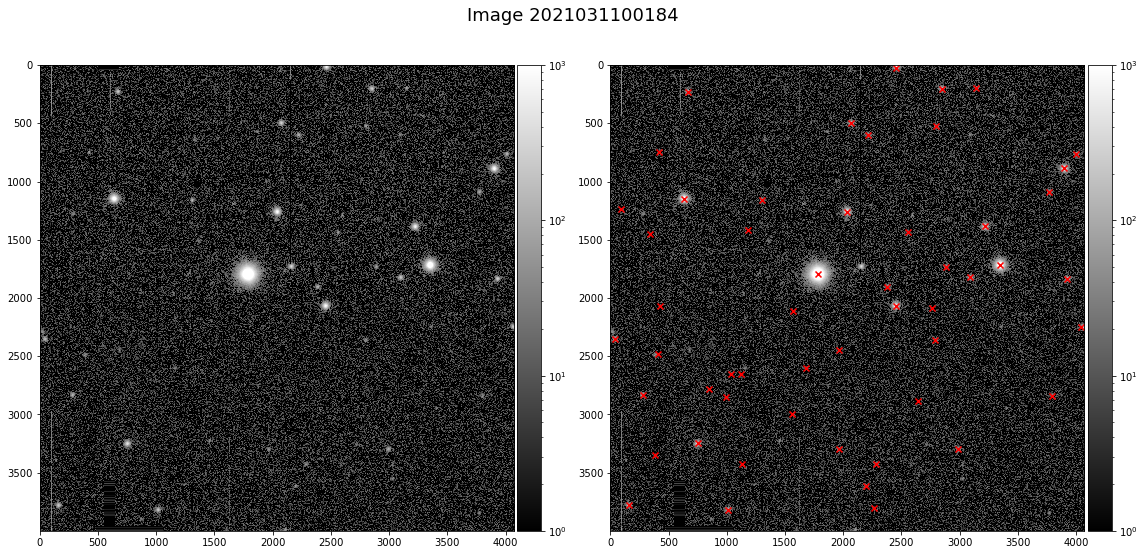

In [8]:
# Look at the data with matplotlib
# Overlay the sourceCatalog with red x's
# It found most source, but not all
from matplotlib.colors import LogNorm
# Now let's look at them
def colorbar(mappable):
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    last_axes = plt.gca()
    ax = mappable.axes
    fig = ax.figure
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(mappable, cax=cax)
    plt.sca(last_axes)
    return cbar

plt.figure(figsize=(16,8))
plt.suptitle(f"Image {expId}",fontsize=18)
plt.subplot(1,2,1)
arr = exp.image.array
arr = np.clip(arr, 1, 100000) # This image has some negative values, and this removes them
img = plt.imshow(arr, norm=LogNorm(vmin=1, vmax=1000),  interpolation='Nearest', cmap='gray')
colorbar(img)
plt.subplot(1,2,2)
img = plt.imshow(arr, norm=LogNorm(vmin=1, vmax=1000),  interpolation='Nearest', cmap='gray')
plt.scatter(sourceCatalog['base_SdssCentroid_x'],sourceCatalog['base_SdssCentroid_y']\
            ,color='red', marker='x')
colorbar(img)
plt.tight_layout(h_pad=1)
#plt.savefig(REPO_DIR+"/plots/NGC4755_17Feb21.pdf")